# 1.Estimativa de gastos em saúde com modelo de regressão linear (freecodecamp)

- Objetivo: utilizar modelo de regressão linear para prever de gastos em dolares em saúde da amostra

- Erro médio absoluto (média dos erros entre valores preditos e valores reais) deve ser menor ou igual a 3500

- Bonus: utilizar modelo de classificação para prever se indivíduo é ou não tabagista

# 2.Carregando bibliotecas e dataset

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import naive_bayes
from xgboost import XGBClassifier
import xgboost as xgb

plt.style.use('ggplot')

## 2.1.Averiguando informações basicas do dataset

In [2]:
dataset = pd.read_csv(r'../gastos_saude.csv', sep=',')

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
dataset.sample(10)

,age,sex,bmi,children,smoker,region,expenses
1045,43,female,24.7,2,yes,northwest,21880.82
962,63,female,35.2,1,no,southeast,14474.68
874,44,male,21.9,3,no,northeast,8891.14
195,19,male,30.6,0,no,northwest,1639.56
149,19,male,28.4,1,no,southwest,1842.52
361,35,male,30.5,1,no,southwest,4751.07
988,34,male,34.7,0,no,northeast,4518.83
843,57,female,29.8,0,yes,southeast,27533.91
572,30,female,43.1,2,no,southeast,4753.64
415,43,female,35.6,1,no,southeast,7345.73


Temos um dataset com 1338 observações, com 7 colunas (variáveis) e nenhuma variável com valores nulos.

# 3.Exploração do dataset e análise

## 3.1.Análise univariada - Variáveis numéricas

In [4]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.00,27.0000,39.00,51.000,64.00
bmi,1338.0,30.665471,6.098382,16.00,26.3000,30.40,34.700,53.10
children,1338.0,1.094918,1.205493,0.00,0.0000,1.00,2.000,5.00
expenses,1338.0,13270.422414,12110.011240,1121.87,4740.2875,9382.03,16639.915,63770.43


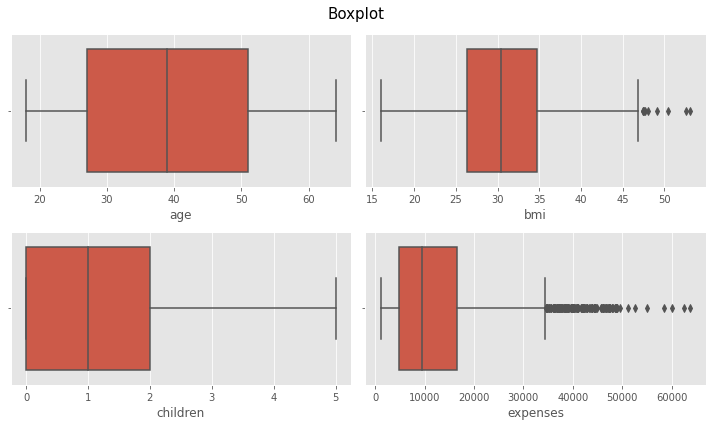

In [5]:
numericos = dataset.select_dtypes(include="number").columns

plt.figure(figsize=(10,6))
plt.suptitle('Boxplot', fontsize=15)

for num, item in enumerate(numericos):
    plt.subplot(2, 2, num+1)
    sns.boxplot(data=dataset, x=item)

plt.tight_layout()

Pela tabela e pelos boxplots podemos observar que age (idade) apresenta distribuição normal, assim como bmi (imc) que apresenta alguns outliers, e expenses (gastos) notadamente não apresenta distribuição normal. Veremos como os dados se apresentam no histograma.

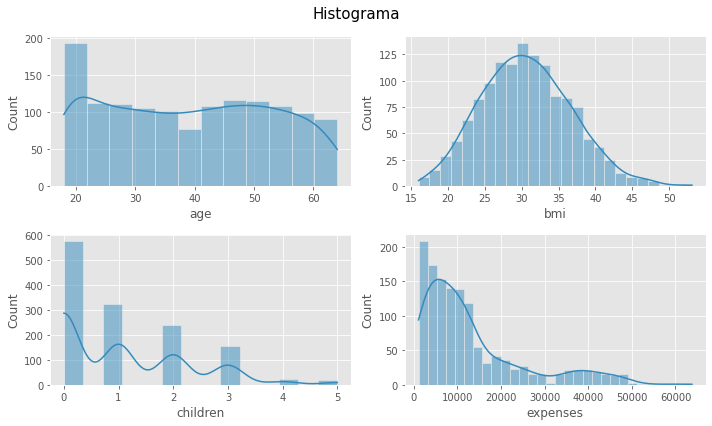

In [6]:
numericos = dataset.select_dtypes(include="number").columns

plt.figure(figsize=(10,6))
plt.suptitle('Histograma', fontsize=15)

for num, item in enumerate(numericos):
    plt.subplot(2, 2, num+1)
    sns.histplot(data=dataset, x=item, kde=True)

plt.tight_layout()

A variável bmi (indice de massa corporal) aparentemente possui distribuição normal, enquanto expenses (gastos) se mostra assimetrica (positiva) e age (idade) apresenta curtose platicurtica. Análises futuras serão feitas para averiguar essas hipoteses. A variável children (filhos) será melhor avaliada na proxima sessão.

## 3.2.Análise univariada - Variáveis categóricas

In [7]:
dataset.describe(include='object')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [8]:
categorias = dataset.select_dtypes(include="object").columns
for item in categorias:
    print(dataset[item].value_counts().to_frame().T)
    print('-'*50)

     male  female
sex   676     662
--------------------------------------------------
          no  yes
smoker  1064  274
--------------------------------------------------
        southeast  southwest  northwest  northeast
region        364        325        325        324
--------------------------------------------------


* Averiguando a contagem da quantidade de filhos por pessoas

In [9]:
dataset['children'].value_counts().to_frame().T

,0,1,2,3,4,5
children,574,324,240,157,25,18


Pessoas com mais de 3 filhos formam um grupo muito pequeno de pessoas, e isso poderia dificultar a análise e entendimento dos dados. Por isso esses inivíduos serão agrupados com aqueles que tem 3 filhos, formando um grupo de 3 ou mais filhos. A variável também foi convertida em categoria para possível análise futura.

In [10]:
dataset['children_'] = dataset['children'].apply(lambda x: '>= 3' if x >= 3 else x)
dataset['children_'] = dataset['children_'].astype('object')

In [11]:
categorias = dataset.select_dtypes(include="object").columns
for item in categorias:
    print(dataset[item].value_counts().to_frame().T)
    print('-'*50)

     male  female
sex   676     662
--------------------------------------------------
          no  yes
smoker  1064  274
--------------------------------------------------
        southeast  southwest  northwest  northeast
region        364        325        325        324
--------------------------------------------------
             0    1    2  >= 3
children_  574  324  240   200
--------------------------------------------------


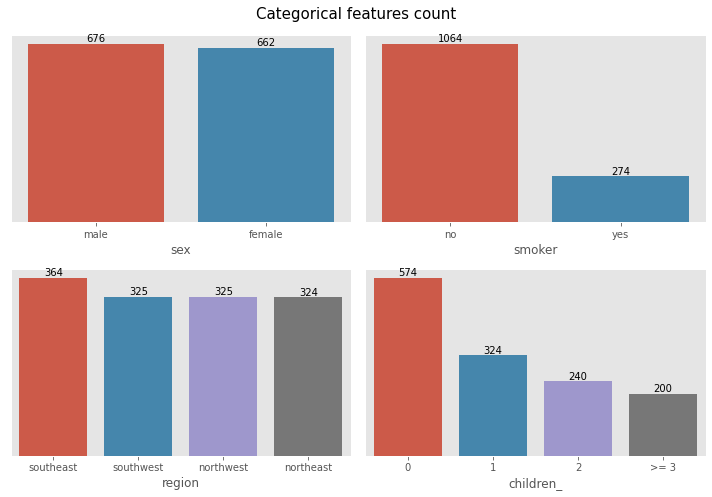

In [12]:
plt.subplots(figsize=(10, 7))
plt.suptitle('Categorical features count', fontsize=15)

for num, item in enumerate(categorias):
    plt.subplot(2, 2, num+1)
    ax = sns.countplot(data=dataset, x=item, order=dataset[item].value_counts().index)
    ax.bar_label(ax.containers[0])
    ax.set_yticks([])
    ax.set(ylabel='')

plt.tight_layout()

É possível já observar proporções diferentes entre pessoas não fumantes e fumantes ( razão proxima de 4 para 1) e a quantidade de filhos por pessoas (predominante pessoas sem filhos, e quanto maior a quantidade de filhos menor numero de pessoas no grupo). Essas variáveis serão avaliadas posteriormente para averiguar possível influencia no modelo. 

## 3.3.Análise bivariada - variáveis numéricas

### 3.3.1.Pairplot

- Com pairplot podemos analisar a relação entre as variáveis numéricas, tanto para começar a entender qual a influencia nos gastos, quanto a relação entre elas.

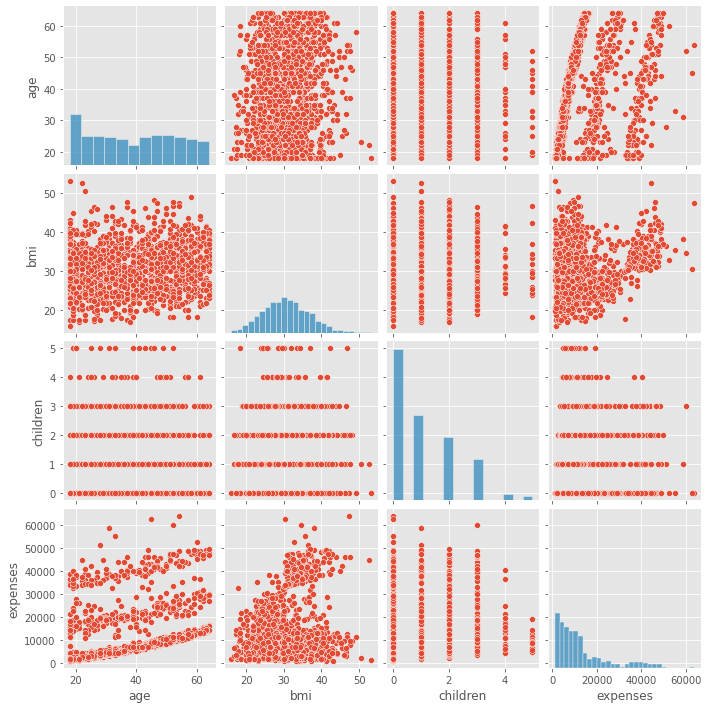

In [13]:
sns.pairplot(dataset)

### 3.3.2.Grafico de dispersão com 'hue'

- Aprofundando mais a análise, usando grafico de dispersão com 'hue', podemos observar que quando incluimos as variáveis categóricas no gráfico de dispersão começamos a ver padrões que podem diferenciar os indivíduos da população, assim como iniciar a compreensão de quais variáveis são mais importantes para os modelos.

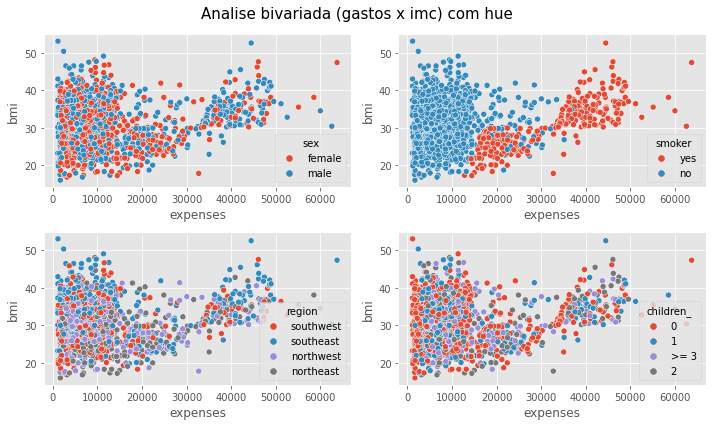

In [14]:
plt.figure(figsize=(10,6))
plt.suptitle('Analise bivariada (gastos x imc) com hue', fontsize=15)

for num, item in enumerate(categorias):
    plt.subplot(2, 2, num+1)
    sns.scatterplot(data=dataset, x='expenses', y='bmi', hue=item)

plt.tight_layout()

É possivel ver que o fato da pessoa ser ou não tabagista diferencia os gastos com saúde em relação ao imc.

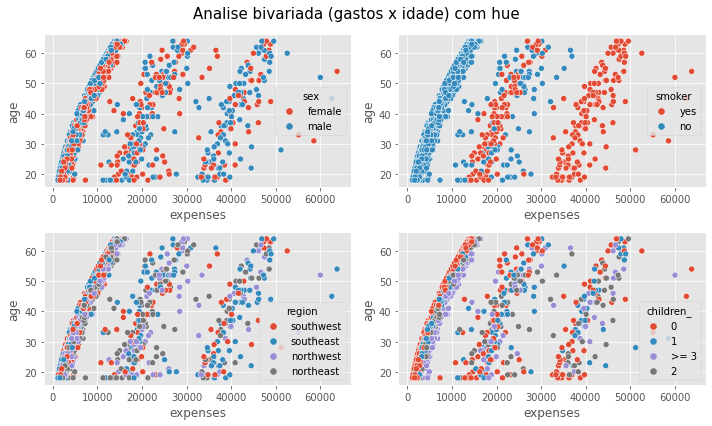

In [15]:
plt.figure(figsize=(10,6))
plt.suptitle('Analise bivariada (gastos x idade) com hue', fontsize=15)

for num, item in enumerate(categorias):
    plt.subplot(2, 2, num+1)
    sns.scatterplot(data=dataset, x='expenses', y='age', hue=item)

plt.tight_layout()

O mesmo também ocorre em relação a idade. Aparentemente a idade já tem algum peso em diferenciar os gastos, porém quando separamos quem é ou não tabagista é possível verificar que acima de 3000 em gastos predominantemente os indivíduos são tabagistas.

### 3.3.3.Grafico de dispersão com 'hue' estipulando pontos de corte

- Apesar de o imc sozinho não ser um bom parametro para avaliar a composição corporal e saúde (pessoas com alto imc não necessariamente são sobrepeso/obesos e pessoas com baixo imc também não é bom indicador de saúde) sabemos pela literatura que imc e idade podem ter contribuição nos gastos em saúde. Então foram estipulados alguns parametros para entender se isso se aplica a população estudada. 

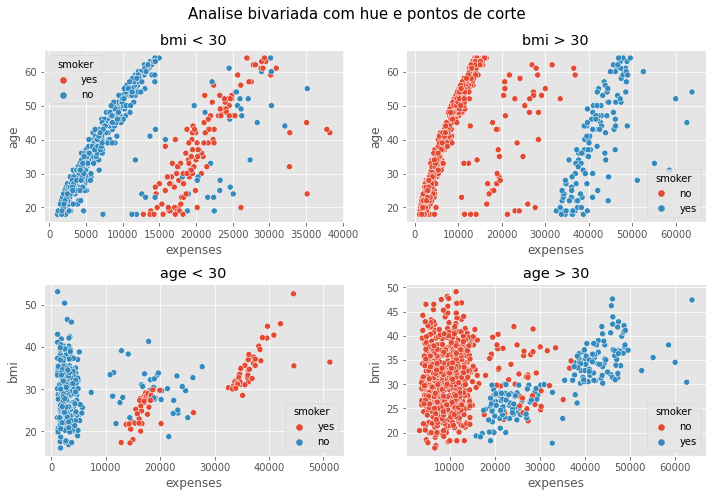

In [16]:
plt.figure(figsize=(10,7))
plt.suptitle('Analise bivariada com hue e pontos de corte', fontsize=15)

plt.subplot(2, 2, 1).set_title('bmi < 30')
sns.scatterplot(data=dataset[dataset['bmi'] < 30], x='expenses', y='age', hue='smoker')
plt.subplot(2, 2, 2).set_title('bmi > 30')
sns.scatterplot(data=dataset[dataset['bmi'] > 30], x='expenses', y='age', hue='smoker')
plt.subplot(2, 2, 3).set_title('age < 30')
sns.scatterplot(data=dataset[dataset['age'] < 30], x='expenses', y='bmi', hue='smoker')
plt.subplot(2, 2, 4).set_title('age > 30')
sns.scatterplot(data=dataset[dataset['age'] > 30], x='expenses', y='bmi', hue='smoker')


plt.tight_layout()

Foram estipulados valores aleatórios, porem isso ja consegue separar determinado conjunto da nossa amostra.

### 3.3.4.Análise bivariada - variáveis categoricas

- Analisando o gasto em saúde levando em conta os grupos presentes podemos identificar possíveis caracteristicas que influenciam no desfecho de gastos.

In [17]:
dataset.groupby('sex')['expenses'].describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
female,662.0,12569.578897,11128.703817,1607.51,4885.1625,9412.965,14454.690,63770.43
male,676.0,13956.751420,12971.025897,1121.87,4619.1350,9369.615,18989.595,62592.87


Homens e mulheres tem gastos similares, porém é interessante observar que há valores distorcendo a média (em relação a mediana).

In [18]:
dataset.groupby('smoker')['expenses'].describe()

,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
no,1064.0,8434.268449,5993.781756,1121.87,3986.4425,7345.405,11362.890,36910.61
yes,274.0,32050.231971,11541.547338,12829.46,20826.2450,34456.350,41019.205,63770.43


Tabagistas apresentam nitidamente gastos mais elevados. Podemos notar que a distorção da média em relação a mediana é menos evidente em relação ao genero.

In [19]:
dataset.groupby('region')['expenses'].describe()

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
northeast,324.0,13406.384691,11255.802916,1694.80,5194.3225,10057.655,16687.3650,58571.07
northwest,325.0,12417.575169,11072.276880,1621.34,4719.7400,8965.800,14711.7400,60021.40
southeast,364.0,14735.411538,13971.098797,1121.87,4440.8850,9294.130,19526.2875,63770.43
southwest,325.0,12346.937908,11557.179033,1241.57,4751.0700,8798.590,13462.5200,52590.83


A média de gastos de diferentes regiões não oscila de maneira expressiva, porém a mediana apresenta diferenças.

In [20]:
dataset.groupby('children_')['expenses'].describe()

,count,mean,std,min,25%,50%,75%,max
children_,,,,,,,,
0,574.0,12365.975767,12023.294017,1121.87,2734.4200,9856.95,14440.1200,63770.43
1,324.0,12731.171821,11823.631341,1711.03,4791.6450,8483.87,15632.0475,58571.07
2,240.0,15073.564000,12891.368314,2304.00,6284.9375,9264.98,20379.2750,49577.66
>= 3,200.0,14576.000350,11579.518726,3443.06,6653.4750,10483.79,18232.3925,60021.40


Novamente a média de gastos de levando em conta o numero de filhos não oscila de maneira expressiva, porém a mediana apresenta diferenças.

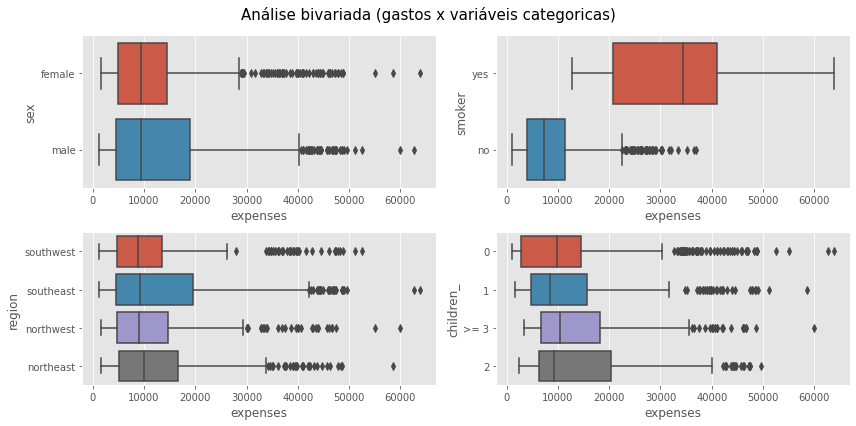

In [21]:
plt.figure(figsize=(12,6))
plt.suptitle('Análise bivariada (gastos x variáveis categoricas)', fontsize=15)

for num, item in enumerate(categorias):
    plt.subplot(2, 2, num+1)
    sns.boxplot(data=dataset, x='expenses', y=item)

plt.tight_layout()

Pelos boxplots é possível observar a diferença visualmente significativa entre os gastos de quem é ou não tabagista. Posteriormente testes estatisticos podem ser aplicados para averiguar a significancia e a magnitude dessa diferença.

- Podemos também aprofundar mais o entendimento de como as variáveis categóricas interagem entre si e possivelmente influenciam o modelo

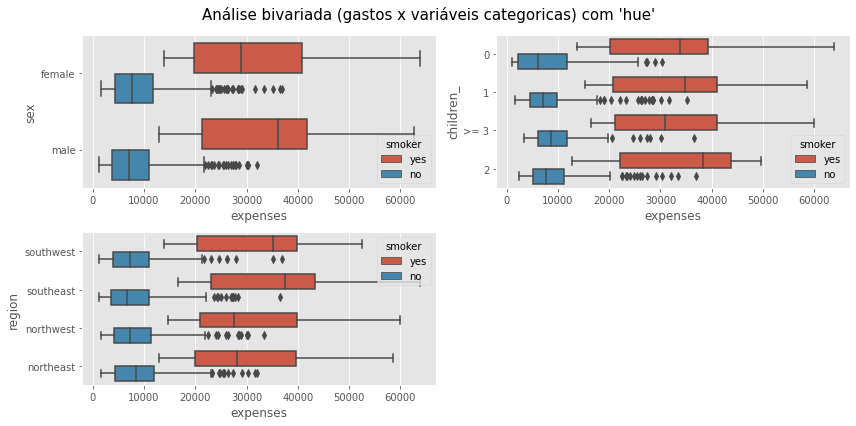

In [22]:
categorias2 = ['sex', 'children_', 'region']

plt.figure(figsize=(12,6))
plt.suptitle("Análise bivariada (gastos x variáveis categoricas) com 'hue'", fontsize=15)

for num, item in enumerate(categorias2):
    plt.subplot(2, 2, num+1)
    sns.boxplot(data=dataset, x='expenses', y=item, hue='smoker')

plt.tight_layout()

Visualmente é nitido que os tabagistas tem maior gastos em saúde dentro de determinado grupo, porém há presença de muitos outliers, e isso ao final pode não influenciar no modelo.

- Agrupando os indivíduos em grupos de quem é ou não tabagistas, podemos identificar também outros subgrupos que podem ter influencia em análises futuras.

In [23]:
dataset.groupby('smoker')['region'].value_counts().to_frame()

region
smoker region           
no     southeast     273
       northwest     267
       southwest     267
       northeast     257
yes    southeast      91
       northeast      67
       northwest      58
       southwest      58

In [24]:
dataset.groupby('smoker')['sex'].value_counts().to_frame()

sex
smoker sex        
no     female  547
       male    517
yes    male    159
       female  115

In [25]:
dataset.groupby('smoker')['children_'].value_counts().to_frame()

children_
smoker children_           
no     0                459
       1                263
       2                185
       >= 3             157
yes    0                115
       1                 61
       2                 55
       >= 3              43

Com essas informações seria interessante aplicação de testes estatisticos, como chi quadrado, para identificar possíveis diferenças entre a frequencia de indivíduos fumantes em um determinado grupo (ex: há mais fumantes homens ou mulheres?). Isso poderia trazer alguns insights futuros para analises.

# 4.Prevendo Gastos

## 4.1.Criação de variáveis 'dummies' para utilização no modelo de regressão linear

In [26]:
sex_dummies = pd.get_dummies(dataset['sex'], prefix='sex', prefix_sep='_')
smoker_dummies = pd.get_dummies(dataset['smoker'], prefix='smoker', prefix_sep='_')
region_dummies = pd.get_dummies(dataset['region'], prefix='region', prefix_sep='_')

In [27]:
df = pd.concat([dataset, sex_dummies, smoker_dummies, region_dummies], axis=1)
df.head()

,age,sex,bmi,children,smoker,region,expenses,children_,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,female,27.9,0,yes,southwest,16884.92,0,1,0,0,1,0,0,0,1
1,18,male,33.8,1,no,southeast,1725.55,1,0,1,1,0,0,0,1,0
2,28,male,33.0,3,no,southeast,4449.46,>= 3,0,1,1,0,0,0,1,0
3,33,male,22.7,0,no,northwest,21984.47,0,0,1,1,0,0,1,0,0
4,32,male,28.9,0,no,northwest,3866.86,0,0,1,1,0,0,1,0,0


## 4.2.Utilizando mapa de calor para selação das variáveis do modelo

- Diversas formas podem ser aplicadas para identificar e selecionar as melhores variáveis para o modelo. No caso apresentado utilizarei um metodo que apesar de suas fraquezas ainda pode ser utilizado de maneira relativamente confiável. A aplicação de testes estatisticos e outros recursos são mais robustos, mas no momento o objetivo desse trabalho é colocar em prática as tecnicas ja conhecidas de maneira facil e rápida.

<AxesSubplot:>

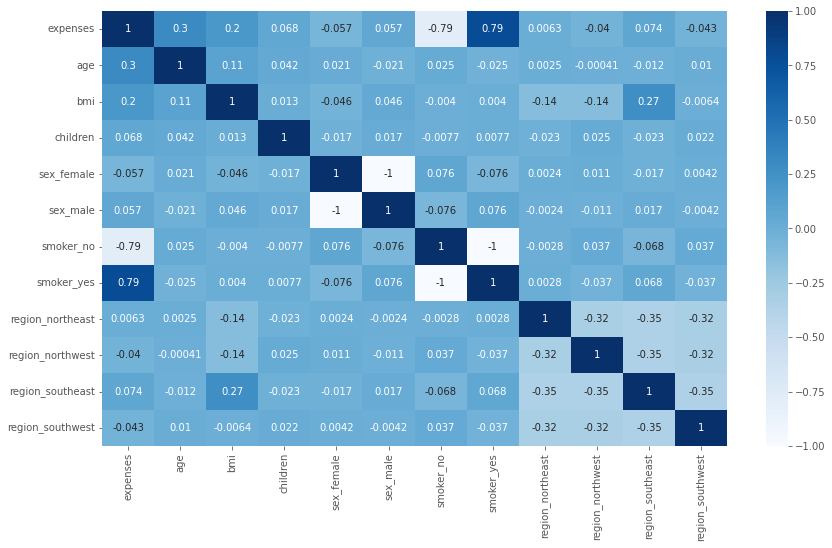

In [28]:
plt.figure(figsize=(14,8))

sns.heatmap(df[['expenses', 'age', 'bmi', 'children', 'sex_female', 
                'sex_male', 'smoker_no', 'smoker_yes', 'region_northeast', 
                'region_northwest', 'region_southeast', 'region_southwest']].corr(), 
            annot=True, cmap='Blues')

Podemos identificar as melhores variáveis de acordo com o indice de correlação. São elas idade, imc e tabagismo.

<AxesSubplot:>

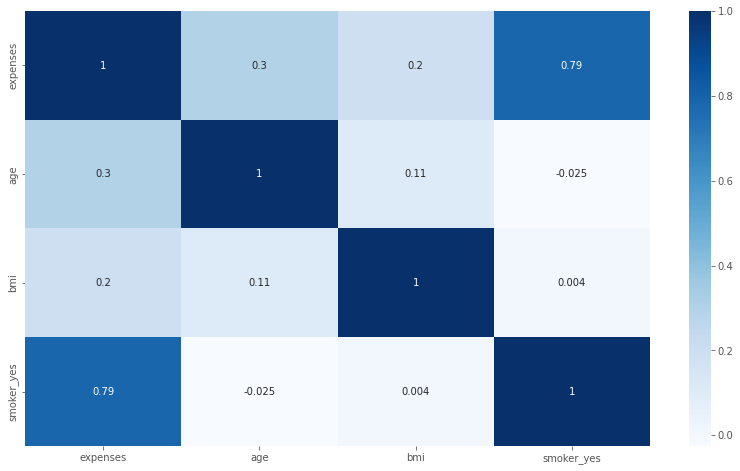

In [29]:
plt.figure(figsize=(14,8))

sns.heatmap(df[['expenses', 'age', 'bmi', 'smoker_yes']].corr(), 
            annot=True, cmap='Blues')

In [30]:
df[['expenses', 'age', 'bmi', 'smoker_yes']].corr()['expenses'].sort_values(ascending=False).to_frame()

,expenses
expenses,1.000000
smoker_yes,0.787251
age,0.299008
bmi,0.198576


Ser tabagista tem o maior indice, seguido pela idade e imc.

## 4.3.Modelo de regressão linear

### 4.3.1.Selecionando variáveis e dividindo o dataset

In [31]:
x_data = df[['age', 'bmi', 'smoker_yes']]
y_data = df['expenses']

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.3, random_state=1)

   ### 4.3.2.Treinando o modelo

In [32]:
lm = LinearRegression()
lm.fit(x_train, y_train)
print(f'Intercepto do modelo de regressão linear: {lm.intercept_.round(3)}' )
print(f'Coeficientes do modelo de regressão linear: {lm.coef_.round(3)}')
print(f'Escore do modelo de regressão linear: {lm.score(x_train, y_train).round(3)}')

Intercepto do modelo de regressão linear: -10866.486
Coeficientes do modelo de regressão linear: [  252.856   305.477 24021.446]
Escore do modelo de regressão linear: 0.752


Podemos interpretar o modelo pela formula de regressão: y = intercepto + 252(idade) + 305(imc) + 24021(fumante). Os valores estão arredondados para facilitar.
O intercepto seria onde o nosso modelo inicia no eixo vertical, no caso -10866, e a cada unidade da idade do indivíduo são adicionados 252 dolares, a cada unidade de imc do indivíduo são adicionados 305 dolares e se o indivíduo for tabagista são adicionados astronomicos 24 MIL dolares. 
Ou seja, um indivíduo de 35 anos, com imc de 25 e não fumante gastara em média (-10866) + (35x252) + (25x305) + (0) = 5.579 dolares.
Já o escore do modelo mostra a porcentagem que o nosso modelo conseguiu explicar da variação dos dados de gastos, ou seja por volta de 75% do valor de gastos em saúde o modelo conseguiu explicar.

   ### 4.3.3.Testando o modelo

In [33]:
Yhat = lm.predict(x_test)
mse = metrics.mean_squared_error(y_test, Yhat)
print(f'Erro quadrado médio do modelo:{mse.round(3)}')
result = pd.DataFrame(Yhat, y_test)
result.reset_index(inplace=True)
result.columns = ['predicted', 'real']
result['dif'] = result['real'] - result['predicted']
result.round(2)

Erro quadrado médio do modelo:37560993.763


,predicted,real,dif
0,1646.43,4782.21,3135.78
1,11353.23,13168.83,1815.60
2,8798.59,13331.81,4533.22
3,10381.48,12703.91,2322.43
4,2103.08,1255.62,-847.46
...,...,...,...
397,11566.30,16040.31,4474.01
398,1880.49,4363.01,2482.52
399,2457.21,2988.37,531.16
400,17043.34,28007.64,10964.30


In [34]:
erro = metrics.mean_absolute_error(y_test, Yhat)

print(f'Erro médio absoluto: {erro}')
if erro > 3500:
    print(f'Erro médio absoluto acima do parametro válido')
else:
    print(f'Erro médio absoluto dentro do parametro válido')

Erro médio absoluto: 4187.014946800531
Erro médio absoluto acima do parametro válido


Modelo ainda não atingiu o valor minimo para erro médio absoluto

### 4.3.4.Validação cruzada

- Com a validação cruzada dividimos os dados e n partes , no caso foi estipulado em 4, assim 3 partes são usadas para treinar o modelo e uma parte é usada para teste. o Escore então é obtido, e o processo é repetido de maneira consecutiva, sendo utilizado diferentes partes para treino e teste, mas sempre nessa proporção, 3 partes para treino e 1 para teste. Assim obtemos 4 escores, e conseguimos mensurar o quão confiável é nosso modelo. 

In [35]:
score = cross_val_score(lm, x_data, y_data, cv=4)
np.mean(score).round(3)

0.745

In [36]:
predict = cross_val_score(lm, x_data, y_data, cv=4)
predict.round(3)

array([0.768, 0.718, 0.761, 0.732])

No caso do modelo em questão, em média foi conseguiu prever gastos em saúde de 71 a 76%. Nada mal para um modelo simples e sem ajustes.

## 4.4.Modelo de regressão linear com função polinomial

- Adicionar uma função polinomial pode ser um recurso para ajustar melhor o modelo aos dados. No caso ao invés de traçarmos uma linha reta para construir o modelo uma função polinomial é utilizada para criar uma linha curva que melhor se ajuste aos dados. Ela é um recurso interessante porém se usada de maneira indiscriminada pode ocasionar overfitting, que em resumo é quando o modelo se ajusta e aprende tão bem o os dados que ele consegue prever com uma precisão muito grande os dados estudados, porém não seria util para ser utilizado em dados novos, se tornando assim inutil.

### 4.4.1.Encontrando o grau mais adequado para o modelo

- Iterando pelo modelo para averiguar melhores escores

In [37]:
lmpoly = LinearRegression()

r2_test = []

order = [2, 3, 4, 5, 6, 7, 8, 9]

for n in order:
    pr = PolynomialFeatures(degree = n)
    x_train_pr = pr.fit_transform(x_train)
    x_test_pr =  pr.fit_transform(x_test)
    lmpoly.fit(x_train_pr, y_train)
    r2_test.append(lmpoly.score(x_test_pr, y_test))

- Criando dataframe com os resultados

In [38]:
r2 = pd.DataFrame(order, r2_test)
r2.reset_index(inplace=True)
r2.columns = ['r²', 'polly_degree']
r2.sort_values(by='r²', ascending=False)

,r²,polly_degree
4,0.852271,6
3,0.850018,5
2,0.847072,4
5,0.843513,7
0,0.840873,2
1,0.840698,3
6,0.805382,8
7,0.803484,9


- Gráfico explicativo

Text(6.3, 0.852, 'Melhor grau da função')

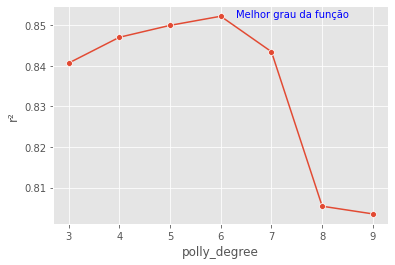

In [39]:
sns.lineplot(data=r2.loc[1:], x='polly_degree', y='r²', marker='o')
plt.text(6.3, 0.852, 'Melhor grau da função', color='blue')

Uma função polinomial de grau 6 é o mais adequado para os dados em questão. Procuramos maximizar o escore (r²) para melhor explicar os gastos atraves do modelo.

### 4.4.2.Criando pipeline para o modelo

- Usaremos standarscaler, a função polinomial e o modelo de regressão

In [40]:
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(degree=5, include_bias=False)), ('model',LinearRegression())]
pipe=Pipeline(Input)

### 4.4.3.Treinando o modelo

In [41]:
pipe.fit(x_train, y_train)
print(f'Intercepto do modelo de regressão linear polinomial de grau 6: {pipe[2].intercept_.round(3)}' )
print(f'Escore do modelo de regressão linear polinomial de grau 6: {pipe.score(x_train, y_train).round(3)}')

Intercepto do modelo de regressão linear polinomial de grau 6: 7152.136
Escore do modelo de regressão linear polinomial de grau 6: 0.852


### 4.4.4.Testando o modelo

In [42]:
Yhat1 = pipe.predict(x_test)
mse = metrics.mean_squared_error(y_test, Yhat1)
print(f'Erro quadrado médio do modelo:{mse.round(4)}')
result1 = pd.DataFrame(Yhat1, y_test)
result1.reset_index(inplace=True)
result1.columns = ['predicted', 'real']
result1['dif'] = result1['real'] - result1['predicted']
result1.round(2)

Erro quadrado médio do modelo:21256384.5549


,predicted,real,dif
0,1646.43,4276.85,2630.42
1,11353.23,14142.09,2788.86
2,8798.59,11731.32,2932.73
3,10381.48,10940.94,559.46
4,2103.08,4483.81,2380.73
...,...,...,...
397,11566.30,13164.10,1597.80
398,1880.49,4539.01,2658.52
399,2457.21,4372.60,1915.39
400,17043.34,20619.65,3576.31


In [43]:
erro1 = metrics.mean_absolute_error(y_test, Yhat1)

print(f'Erro médio absoluto: {erro1}')
if erro1 > 3500:
    print(f'Erro médio absoluto acima do parametro válido')
else:
    print(f'Erro médio absoluto dentro do parametro válido')

Erro médio absoluto: 2756.8735991222898
Erro médio absoluto dentro do parametro válido


Pronto. Foi possível aprimorar o r² de 0.75 para 0.85, e o erro médio absoluto quase mil dolares abaixo do parametro estipulado.

### 4.4.5.Validação cruzada

- Novamente utilizaremos a validação cruzada para averigaur o quão bom, em média, nosso modelo consegue prever os gastos.

In [44]:
score1 = cross_val_score(pipe, x_data, y_data, cv=4)
np.mean(score1).round(4)

0.8397

In [45]:
predict1 = cross_val_score(pipe, x_data, y_data, cv=4)
predict1.round(4)

array([0.8737, 0.801 , 0.8657, 0.8184])

O modelo final, em média conseguiu prever gastos em saúde de 80 a 87%.

# 5.Bonus - predizendo tabagismo

Utilizaremos os mesmos dados, porém tendo utilizando tabagismo como variável dependente

## 5.1.Selecionando variaveis e dividindo dataset

In [46]:
Xlog = df[['expenses', 'age', 'bmi']]
Ylog = df['smoker_yes']

Xlog_train, Xlog_test, Ylog_train, Ylog_test = train_test_split(Xlog, Ylog, test_size = 0.3, random_state=10)


## 5.2.Modelo de regressão logistica

### 5.2.1.Treinando e testando o modelo

In [47]:
lr = LogisticRegression()
lr.fit(Xlog_train, Ylog_train)
Yhat_log = lr.predict(Xlog_test)

## 5.3.Modelo de arvore de decisão

### 5.3.1.Treinando e testando o modelo

In [48]:
treeclass = DecisionTreeClassifier(criterion='entropy', max_depth=4, ccp_alpha=0.01)
treeclass.fit(Xlog_train, Ylog_train)
Yhat_tree = treeclass.predict(Xlog_test)

- Averiguando a importancia das variáveis para o modelo

In [49]:
importance = pd.DataFrame(treeclass.feature_importances_, index=['expenses', 'age', 'bmi'])
importance.columns = ['importance']
importance.sort_values(by='importance', ascending=False)

,importance
expenses,0.855900
bmi,0.132618
age,0.011482


<AxesSubplot:>

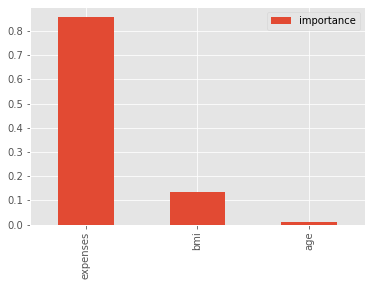

In [50]:
importance.sort_values(by='importance', ascending=False).plot(kind='bar')

- Representaçaõ do modelo de arvore de decisão

[Text(0.4230769230769231, 0.9, 'expenses <= 14453.74\nentropy = 0.734\nsamples = 936\nvalue = [743, 193]\nclass = no'),
 Text(0.23076923076923078, 0.7, 'bmi <= 21.75\nentropy = 0.052\nsamples = 677\nvalue = [673, 4]\nclass = no'),
 Text(0.15384615384615385, 0.5, 'expenses <= 12430.895\nentropy = 0.42\nsamples = 47\nvalue = [43, 4]\nclass = no'),
 Text(0.07692307692307693, 0.3, 'entropy = 0.0\nsamples = 40\nvalue = [40, 0]\nclass = no'),
 Text(0.23076923076923078, 0.3, 'entropy = 0.985\nsamples = 7\nvalue = [3, 4]\nclass = yes'),
 Text(0.3076923076923077, 0.5, 'entropy = 0.0\nsamples = 630\nvalue = [630, 0]\nclass = no'),
 Text(0.6153846153846154, 0.7, 'expenses <= 33473.895\nentropy = 0.842\nsamples = 259\nvalue = [70, 189]\nclass = yes'),
 Text(0.46153846153846156, 0.5, 'bmi <= 30.35\nentropy = 0.994\nsamples = 148\nvalue = [67, 81]\nclass = yes'),
 Text(0.38461538461538464, 0.3, 'entropy = 0.788\nsamples = 106\nvalue = [25, 81]\nclass = yes'),
 Text(0.5384615384615384, 0.3, 'entropy 

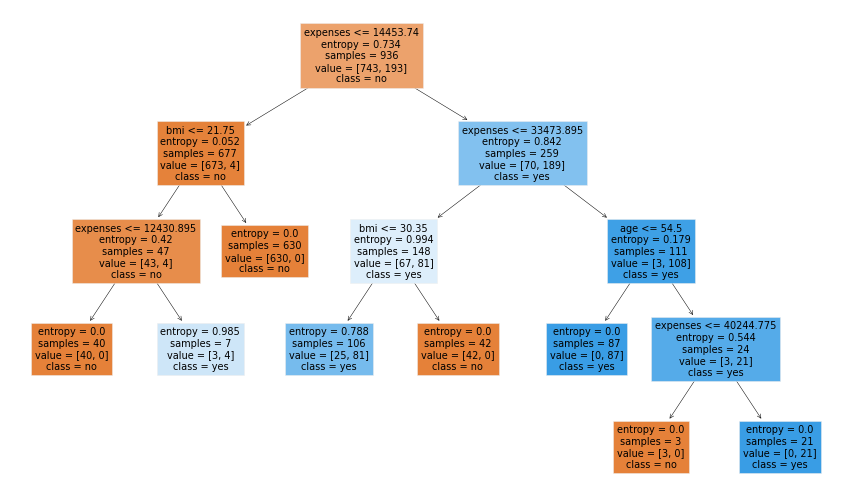

In [51]:
from sklearn import tree
plt.figure(figsize=(15,9))
tree.plot_tree(treeclass, feature_names=['expenses', 'age', 'bmi'], 
               class_names={0:'no', 1:'yes'}, filled=True)

## 5.4.Modelo de random forest

### 5.4.1.Treinando e testando o modelo

In [52]:
rnd_forest = RandomForestClassifier(criterion='entropy', max_depth=4)
rnd_forest.fit(Xlog_train, Ylog_train)
Yhat_forest = rnd_forest.predict(Xlog_test)

- Averiguando a importancia das variáveis para o modelo

In [53]:
importance = pd.DataFrame(rnd_forest.feature_importances_, index=['expenses', 'age', 'bmi'])
importance.columns = ['importance']
importance.sort_values(by='importance', ascending=False)

,importance
expenses,0.872162
bmi,0.071712
age,0.056125


<AxesSubplot:>

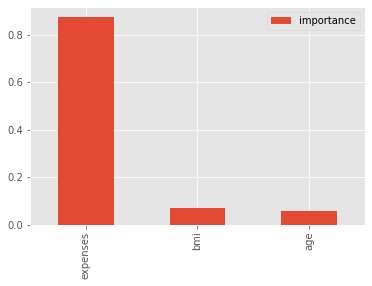

In [54]:
importance.sort_values(by='importance', ascending=False).plot(kind='bar')

## 5.5.Modelo de Naive Bayes (multinomial)

### 5.5.1.Treinando e testando o modelo

In [55]:
mnnb = naive_bayes.MultinomialNB()
mnnb.fit(Xlog_train, Ylog_train)
Yhat_mnnb = mnnb.predict(Xlog_test)

## 5.6.Resumo dos modelos

Metrics for classification with decision tree
Accuracy: 0.958
Precision: 0.827
Recall: 1.0


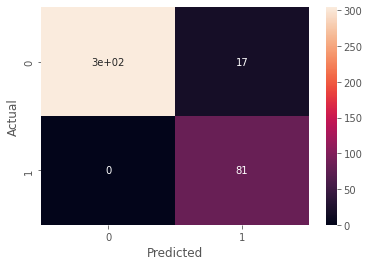

              precision    recall  f1-score   support

           0       1.00      0.95      0.97       321
           1       0.83      1.00      0.91        81

    accuracy                           0.96       402
   macro avg       0.91      0.97      0.94       402
weighted avg       0.97      0.96      0.96       402

------------------------------------------------------
Metrics for classification with random forest
Accuracy: 0.938
Precision: 0.811
Recall: 0.901


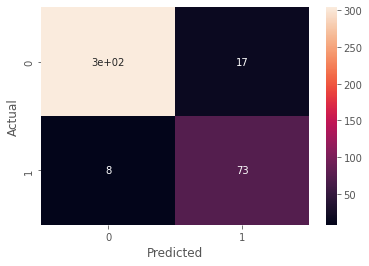

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       321
           1       0.81      0.90      0.85        81

    accuracy                           0.94       402
   macro avg       0.89      0.92      0.91       402
weighted avg       0.94      0.94      0.94       402

------------------------------------------------------
Metrics for classification with multinomial nb
Accuracy: 0.938
Precision: 0.764
Recall: 1.0


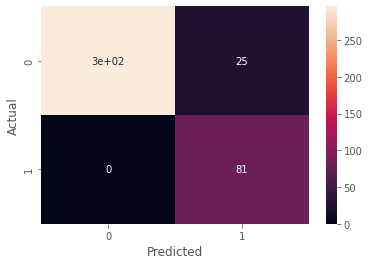

              precision    recall  f1-score   support

           0       1.00      0.92      0.96       321
           1       0.76      1.00      0.87        81

    accuracy                           0.94       402
   macro avg       0.88      0.96      0.91       402
weighted avg       0.95      0.94      0.94       402

------------------------------------------------------
Metrics for classification with logistic
Accuracy: 0.923
Precision: 0.857
Recall: 0.741


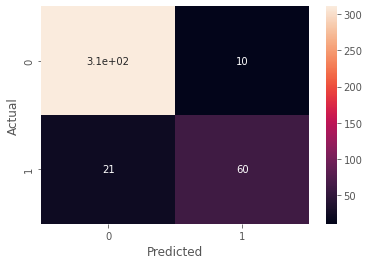

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       321
           1       0.86      0.74      0.79        81

    accuracy                           0.92       402
   macro avg       0.90      0.85      0.87       402
weighted avg       0.92      0.92      0.92       402

------------------------------------------------------
Metrics for classification with xgbclassifier
Accuracy: 0.965
Precision: 0.894
Recall: 0.938


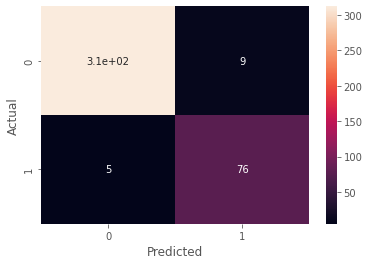

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       321
           1       0.89      0.94      0.92        81

    accuracy                           0.97       402
   macro avg       0.94      0.96      0.95       402
weighted avg       0.97      0.97      0.97       402

------------------------------------------------------


In [60]:
models = {'decision tree':Yhat_tree, 'random forest':Yhat_forest, 'multinomial nb':Yhat_mnnb, 
          'logistic':Yhat_log}

for name, item in models.items():
    print(f'Metrics for classification with {name}')
    print("Accuracy:", metrics.accuracy_score(Ylog_test, item).round(3))
    print("Precision:", metrics.precision_score(Ylog_test, item).round(3))
    print("Recall:", metrics.recall_score(Ylog_test, item).round(3))
    confusion_matrix = pd.crosstab(Ylog_test, item, rownames = ['Actual'], colnames = ['Predicted'])
    sns.heatmap(confusion_matrix, annot=True)
    plt.show()
    print(metrics.classification_report(Ylog_test, item))
    print('-'*54)

De todos os modelos utilizados o de arvore de decisão teve a melhor performance. Com ele foi possível alcançar uma acurácia de quase 96%, sendo possível identificar corretamente todos os indivíduos fumantes (verdadeiros negativos) e 82% dos indivíduos não fumantes (verdadeiros positivos).